In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('world_happiness_2026.csv')

data = df.to_numpy()
score = data[1:, 3]
score = score.astype(dtype=float)

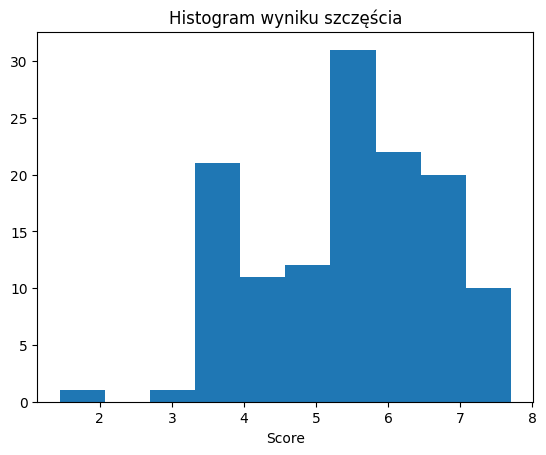

In [2]:
plt.hist(score)
plt.title("Histogram wyniku szczęścia")
plt.xlabel("Score")
plt.show()

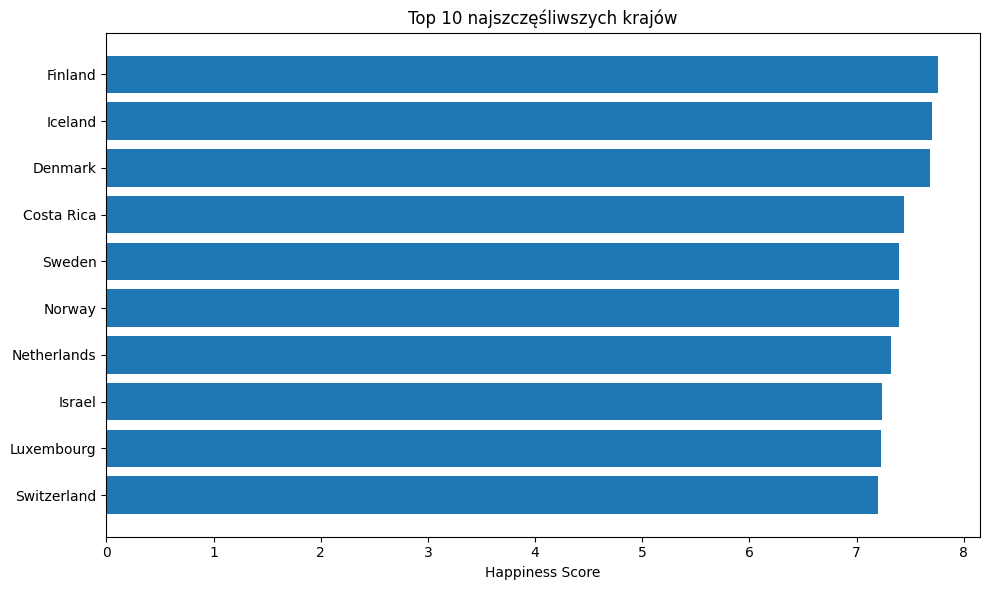

In [3]:
top10 = df.sort_values(by="score", ascending=False).head(10)
bottom10 = df.sort_values(by="score", ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["country"], top10["score"])

plt.title("Top 10 najszczęśliwszych krajów")
plt.xlabel("Happiness Score")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

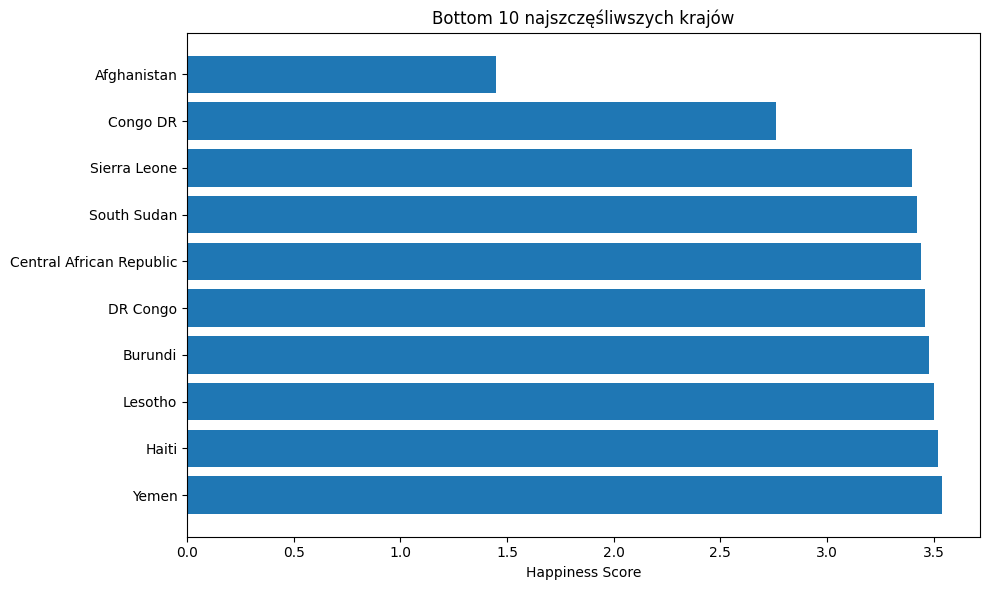

In [4]:
plt.figure(figsize=(10, 6))
plt.barh(bottom10["country"], bottom10["score"])

plt.title("Bottom 10 najszczęśliwszych krajów")
plt.xlabel("Happiness Score")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

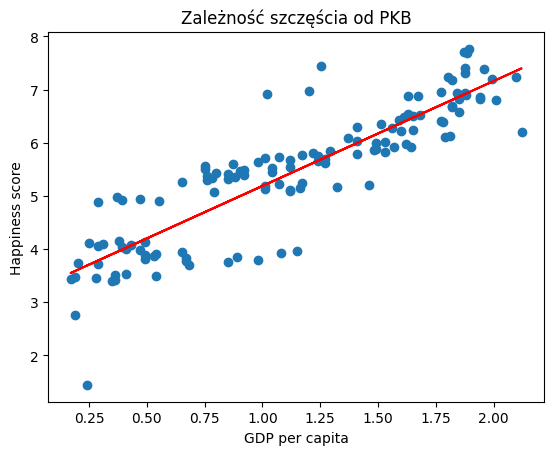

In [5]:
plt.scatter(df["gdp_per_capita"], df["score"])

m, b = np.polyfit(df["gdp_per_capita"], df["score"], 1)
plt.plot(df["gdp_per_capita"], m*df["gdp_per_capita"] + b, color="red")

plt.xlabel("GDP per capita")
plt.ylabel("Happiness score")
plt.title("Zależność szczęścia od PKB")
plt.show()

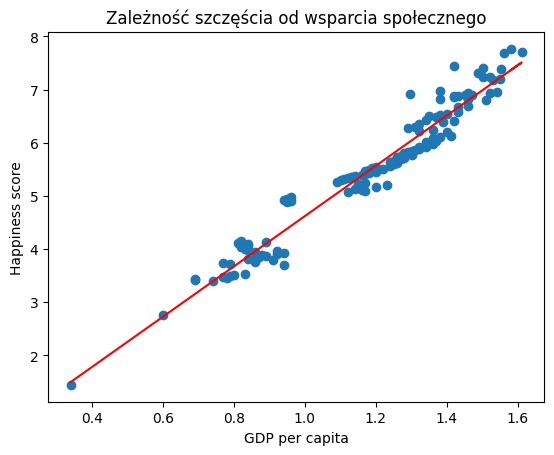

In [6]:
plt.scatter(df["social_support"], df["score"])

m, b = np.polyfit(df["social_support"], df["score"], 1)
plt.plot(df["social_support"], m*df["social_support"] + b, color="red")

plt.xlabel("GDP per capita")
plt.ylabel("Happiness score")
plt.title("Zależność szczęścia od wsparcia społecznego")
plt.show()

region
Sub-Saharan Africa                    4.204256
South Asia                            4.816833
Middle East and North Africa          5.356929
Southeast Asia                        5.694333
Commonwealth of Independent States    5.757000
Latin America and Caribbean           5.874933
East Asia                             6.099200
Central and Eastern Europe            6.551273
North America and ANZ                 6.969000
Western Europe                        6.987167
Name: score, dtype: float64


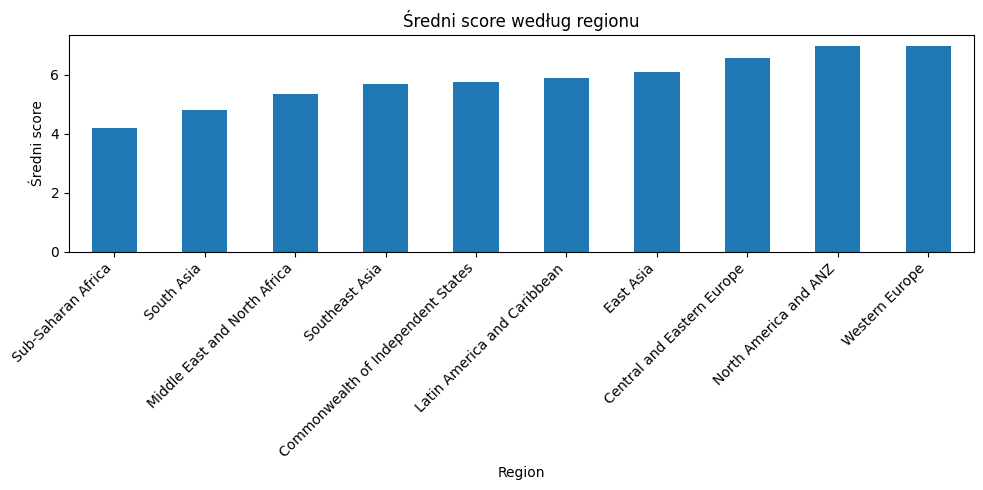

In [7]:
mean = df.groupby(["region"])["score"].mean().sort_values()

print(mean)

mean.plot(kind="bar", figsize=(10,5))

plt.title("Średni score według regionu")
plt.xlabel("Region")
plt.ylabel("Średni score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

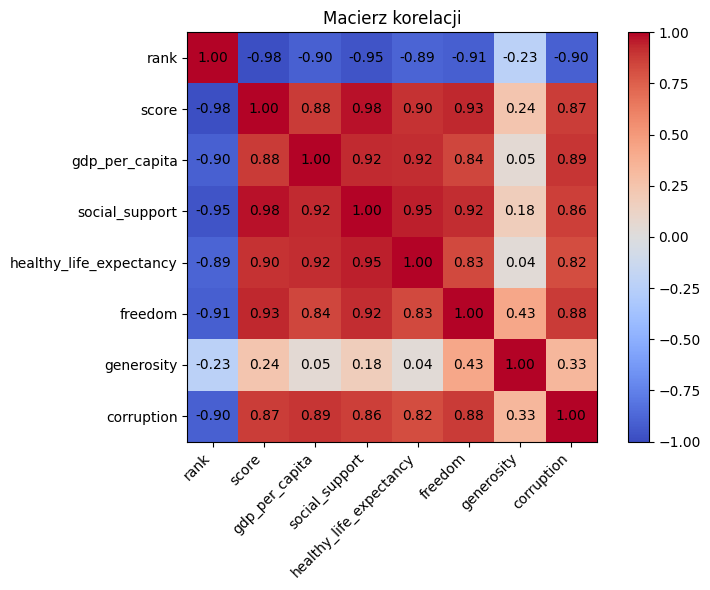

In [8]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))

cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.colorbar(cax)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

In [9]:
df["happiness_level"] = pd.cut(df["score"], bins=3, labels=["Low", "Medium", "High"])
print(df["happiness_level"].value_counts())

happiness_level
High      61
Medium    59
Low       10
Name: count, dtype: int64
